In [10]:
import sys
sys.path.append("..")

from data_ingestion.fetch_valet import get_fx_series
import pandas as pd

df = get_fx_series("FXUSDCAD", "2017-01-01", "2024-12-31")
df.head(10)

,date,rate
0,2017-01-03,1.3435
1,2017-01-04,1.3315
2,2017-01-05,1.3244
3,2017-01-06,1.3214
4,2017-01-09,1.3240
5,2017-01-10,1.3213
6,2017-01-11,1.3250
7,2017-01-12,1.3106
8,2017-01-13,1.3141
9,2017-01-16,1.3152


In [11]:
print(df.shape)        
print(df.dtypes)       
print(df.describe())   
print(df.isnull().sum()) 

(1995, 2)
date    datetime64[us]
rate           float64
dtype: object
                             date         rate
count                        1995  1995.000000
mean   2020-12-28 18:55:23.909774     1.317155
min           2017-01-03 00:00:00     1.204000
25%           2019-01-01 00:00:00     1.280900
50%           2020-12-29 00:00:00     1.321700
75%           2022-12-29 12:00:00     1.350350
max           2024-12-31 00:00:00     1.449600
std                           NaN     0.045674
date    0
rate    0
dtype: int64


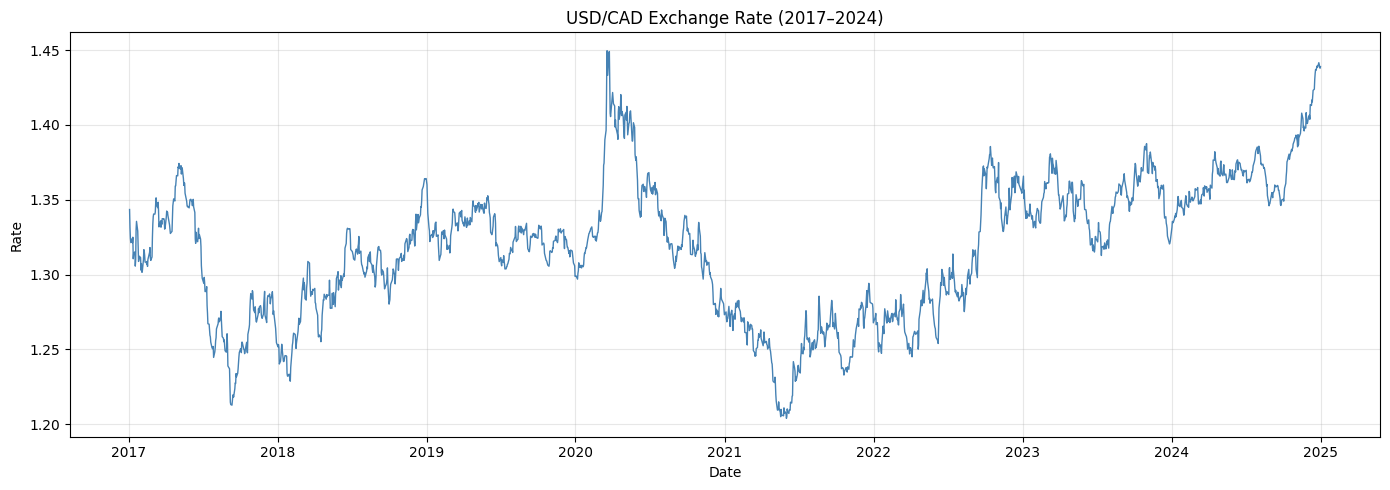

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(df["date"], df["rate"], color="steelblue", linewidth=1)
plt.title("USD/CAD Exchange Rate (2017–2024)")
plt.xlabel("Date")
plt.ylabel("Rate")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

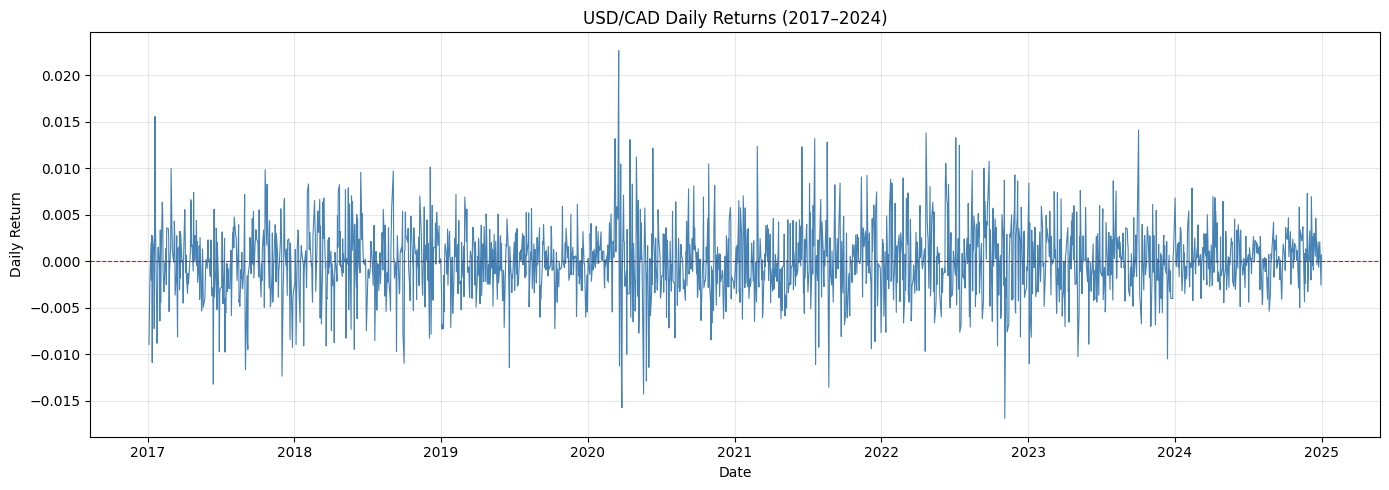

In [13]:
df["daily_return"] = df["rate"].pct_change()

plt.figure(figsize=(14, 5))
plt.plot(df["date"], df["daily_return"], color="steelblue", linewidth=0.8)
plt.title("USD/CAD Daily Returns (2017–2024)")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.axhline(y=0, color="red", linewidth=0.8, linestyle="--")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

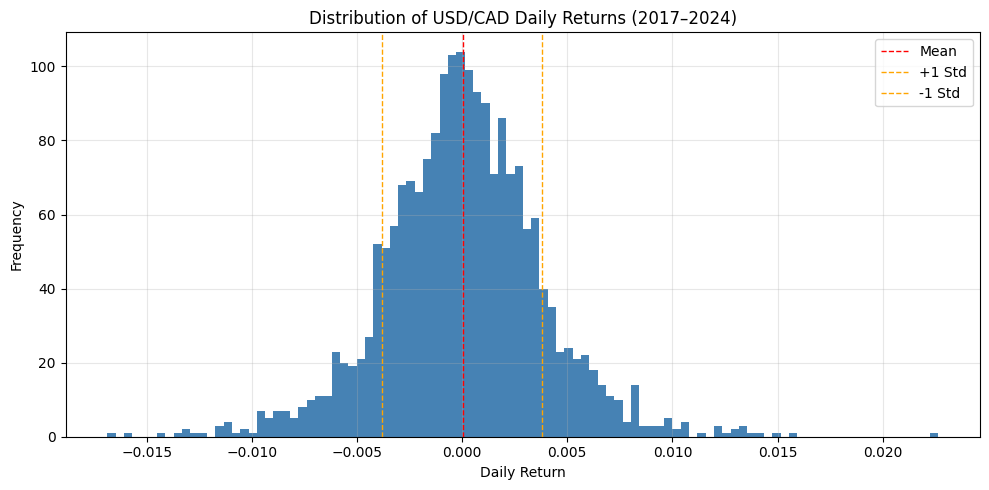

In [14]:
plt.figure(figsize=(10, 5))
plt.hist(df["daily_return"].dropna(), bins=100, color="steelblue", edgecolor="none")
plt.title("Distribution of USD/CAD Daily Returns (2017–2024)")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.axvline(df["daily_return"].mean(), color="red", linestyle="--", linewidth=1, label="Mean")
plt.axvline(df["daily_return"].std(), color="orange", linestyle="--", linewidth=1, label="+1 Std")
plt.axvline(-df["daily_return"].std(), color="orange", linestyle="--", linewidth=1, label="-1 Std")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

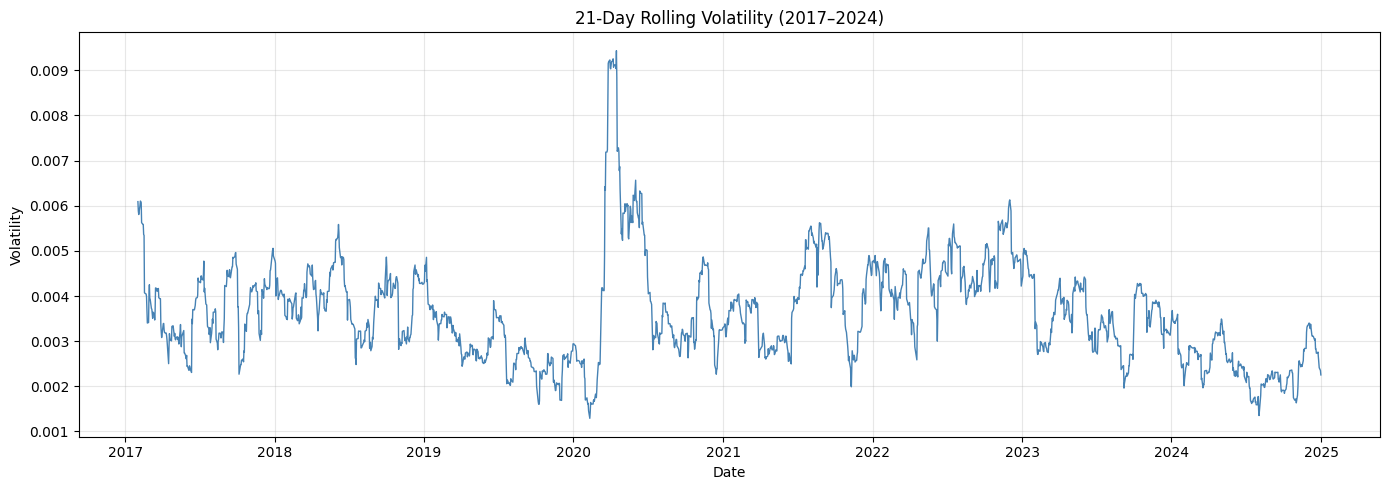

In [15]:
df["rolling_std"] = df["daily_return"].rolling(window=21).std()

plt.figure(figsize=(14, 5))
plt.plot(df["date"], df["rolling_std"], color="steelblue", linewidth=1)
plt.title("21-Day Rolling Volatility (2017–2024)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### EDA Summary

**Dataset:** USD/CAD daily exchange rates, 2017–2024 (1,995 trading days, 0 missing values)

